# Mobile clinic routing in Nyamira County: predicting *while* optimizing with learned constraints

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gromicho/mobile_clinics/blob/main/mobile_clinic_routing.ipynb)

This notebook illustrates the idea behind Intervention I3 of *Domain-Driven Mobile Clinic Routing with Decision Support* (Chapter 6 of Mayukh Ghosh's thesis, joint work of Mayukh Ghosh, Chintan Amrit and Joaquim Gromicho): when the demand a mobile clinic meets at one location depends on **which other locations the clinic visits**, a predict-then-optimize pipeline mis-plans. Embedding the demand model inside the optimization model through **constraint learning** (`gurobi-machinelearning`) fixes this.

We use only open data and no API keys:

| Ingredient | Source |
| --- | --- |
| Ward boundaries (20 wards of Nyamira County, Kenya) | GADM 4.1, level 3 |
| Population per ward | WorldPop 2020, 1 km UN-adjusted raster |
| Road network and health facilities | OpenStreetMap via `osmnx` |
| Network distances between wards | `pandana` contraction hierarchies |
| Demand data | a simulator with an explicit **spillover** term (both signs are shown) |
| Optimization | Gurobi, sized to stay inside the free Community Edition limit (2000 variables and constraints) |

The narrative in one line: the **static** model promises doses it cannot deliver when neighbouring wards cannibalise each other's demand, and under-plans when visits mobilise neighbours; the **learned-constraint** model recovers the oracle plan in both cases.

In [1]:
# Colab setup: installs only what is missing, and fetches the cached data from the GitHub repo so the
# OpenStreetMap download is skipped. Locally, this cell is a no-op when the packages and data/ are present.
import importlib, os, subprocess, sys
need = {"osmnx": "osmnx", "pandana": "pandana", "gurobipy": "gurobipy", "gurobi_ml": "gurobi-machinelearning",
        "geopandas": "geopandas", "rasterio": "rasterio", "folium": "folium", "sklearn": "scikit-learn"}
missing = [pkg for mod, pkg in need.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("missing packages installed:", missing or "none")
if not os.path.isdir("data"):
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/gromicho/mobile_clinics.git", "_repo"], check=True)
    os.chdir("_repo")
    print("cached data fetched from github.com/gromicho/mobile_clinics")

missing packages installed: none


In [2]:
import os, io, time, zipfile, warnings, urllib.request
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, geopandas as gpd
import osmnx as ox, pandana as pdna, rasterio, rasterio.mask
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
from gurobi_ml import add_predictor_constr
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

COUNTY = "Nyamira"          # any Kenyan county works; keep the ward count near 20 for the Community Edition
DATA = "data"               # everything downloaded is cached here
os.makedirs(DATA, exist_ok=True)
SEED = 42
rng = np.random.default_rng(SEED)

CAP = 250.0                 # doses the clinic can administer per visit-day
DOSE_PER_KM = 1.0           # trade-off: one extra km of driving is worth one dose
START_WARD = "Township"     # Nyamira town, county referral hospital: vaccines are collected here

from contextlib import contextmanager
@contextmanager
def timed(label):
    # prints wall-clock time of the expensive steps
    t = time.perf_counter()
    yield
    print(f"[{label}] {time.perf_counter() - t:.1f} s")

## Hands-on parameters

Change **one** value below, run this cell, then rerun the scenario cells in Section 4 (they rebuild what depends on these values). Suggested experiments:

1. **Range.** `R_KM = 5`, then `20`. Does the gap between static and learned grow or shrink? Why?
2. **Stops.** `K_STOPS = 4`, then `12`. At which end can the static planner get away with ignoring spillover?
3. **Model size.** `HIDDEN = (2,)`. Watch the variable count and the realised doses. What did you trade?

A table of answers is at the very end of the notebook.

In [3]:
R_KM = 10.0                 # spillover range in km: neighbours within about this road distance interact
K_STOPS = 8                 # maximum number of wards visited in one planning period
HIDDEN = (8,)               # hidden layer of the demand network that gets embedded in the optimization

## 1. Data

Downloads are cached in `data/`. The OpenStreetMap road graph is the slow one (about 2 to 3 minutes the first time).

In [4]:
def fetch(url, path):
    if not os.path.exists(path):
        print("downloading", url.split("/")[-1])
        urllib.request.urlretrieve(url, path)
    return path

t_data = time.perf_counter()
# Ward boundaries: GADM 4.1 level 3
zpath = fetch("https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_KEN_3.json.zip", f"{DATA}/gadm41_KEN_3.json.zip")
if not os.path.exists(f"{DATA}/gadm41_KEN_3.json"):
    zipfile.ZipFile(zpath).extractall(DATA)
wards = gpd.read_file(f"{DATA}/gadm41_KEN_3.json")
wards = wards[wards.NAME_1 == COUNTY][["NAME_2", "NAME_3", "geometry"]].rename(columns={"NAME_2": "subcounty", "NAME_3": "ward"}).reset_index(drop=True)
n = len(wards)
poly = wards.geometry.union_all()

# Population: WorldPop 2020 1 km UN-adjusted, zonal sum per ward
rpath = fetch("https://data.worldpop.org/GIS/Population/Global_2000_2020_1km_UNadj/2020/KEN/ken_ppp_2020_1km_Aggregated_UNadj.tif",
              f"{DATA}/ken_ppp_2020_1km_Aggregated_UNadj.tif")
with rasterio.open(rpath) as src:
    pops = []
    for geom in wards.geometry:
        arr, _ = rasterio.mask.mask(src, [geom.__geo_interface__], crop=True, nodata=0)
        pops.append(float(np.clip(arr[0], 0, None).sum()))
wards["pop"] = pops
print(f"{COUNTY}: {n} wards, {wards['pop'].sum()/1e3:.0f} thousand people, {wards.to_crs(32736).area.sum()/1e6:.0f} km2")
print(f"[boundaries + population] {time.perf_counter() - t_data:.1f} s")

Nyamira: 20 wards, 745 thousand people, 897 km2
[boundaries + population] 0.5 s


In [5]:
# Roads (drive network) and health facilities from OpenStreetMap
gpath = f"{DATA}/{COUNTY}_drive.graphml"
with timed("road graph " + ("from cache" if os.path.exists(gpath) else "from OpenStreetMap")):
    if os.path.exists(gpath):
        G = ox.load_graphml(gpath)
    else:
        G = ox.graph_from_polygon(poly.buffer(0.02), network_type="drive", simplify=True)
        ox.save_graphml(G, gpath)
print("road graph:", len(G.nodes), "nodes,", len(G.edges), "edges")

fpath = f"{DATA}/{COUNTY}_health.geojson"
with timed("health facilities " + ("from cache" if os.path.exists(fpath) else "from OpenStreetMap")):
    if os.path.exists(fpath):
        fac = gpd.read_file(fpath)
    else:
        fac = ox.features_from_polygon(poly, {"amenity": ["hospital", "clinic", "doctors"], "healthcare": True})
        fac = fac[fac.geometry.notna()].copy()
        fac["geometry"] = fac.geometry.representative_point()
        fac = fac[[c for c in ["name", "amenity", "healthcare"] if c in fac.columns] + ["geometry"]].reset_index(drop=True)
        fac.to_file(fpath, driver="GeoJSON")
print("health facilities tagged in OSM:", len(fac), "(OSM coverage in rural Kenya is thin; the Kenya Master Health Facility Registry would list far more)")

[road graph from cache] 1.4 s
road graph: 6242 nodes, 16975 edges
[health facilities from cache] 0.0 s
health facilities tagged in OSM: 6 (OSM coverage in rural Kenya is thin; the Kenya Master Health Facility Registry would list far more)


In [6]:
# pandana network: ward centroids snapped to the nearest road node, all-pairs road distances, distance to nearest facility
with timed("pandana network build (contraction hierarchies)"):
    nodes, edges = ox.graph_to_gdfs(G)
    edges = edges.reset_index()
    net = pdna.Network(nodes["x"], nodes["y"], edges["u"], edges["v"], edges[["length"]], twoway=False)

cent = wards.to_crs(32736).centroid.to_crs(4326)
wards["lon"], wards["lat"] = cent.x.values, cent.y.values
node_id = net.get_node_ids(cent.x.values, cent.y.values).values

with timed(f"{n}x{n} road distance matrix + nearest facility"):
    dist = np.array(net.shortest_path_lengths(np.repeat(node_id, n), np.tile(node_id, n))).reshape(n, n) / 1000.0
    dist = (dist + dist.T) / 2                       # symmetrise (one-way streets make tiny asymmetries)
    net.set_pois("health", maxdist=80000, maxitems=1, x_col=fac.geometry.x, y_col=fac.geometry.y)
    wards["km_to_facility"] = net.nearest_pois(80000, "health", num_pois=1).loc[node_id, 1].values / 1000.0

start = int(wards.index[wards.ward == START_WARD][0])
wards[["subcounty", "ward", "pop", "km_to_facility"]].round(1)

[pandana network build (contraction hierarchies)] 0.6 s
[20x20 road distance matrix + nearest facility] 0.0 s


,subcounty,ward,pop,km_to_facility
0,Borabu,Esise,33485.2,28.2
1,Borabu,Kiabonyoru,48695.9,4.5
2,Borabu,Mekenene,30263.5,10.1
3,Borabu,Nyansiongo,41198.6,21.3
4,KitutuMasaba,Gachuba,37465.3,3.4
5,KitutuMasaba,Gesima,47747.9,13.7
6,KitutuMasaba,Kemera,48149.1,5.8
7,KitutuMasaba,Magombo,28231.6,3.4
8,KitutuMasaba,Manga,34589.4,4.5
9,KitutuMasaba,Rigoma,48949.0,12.0


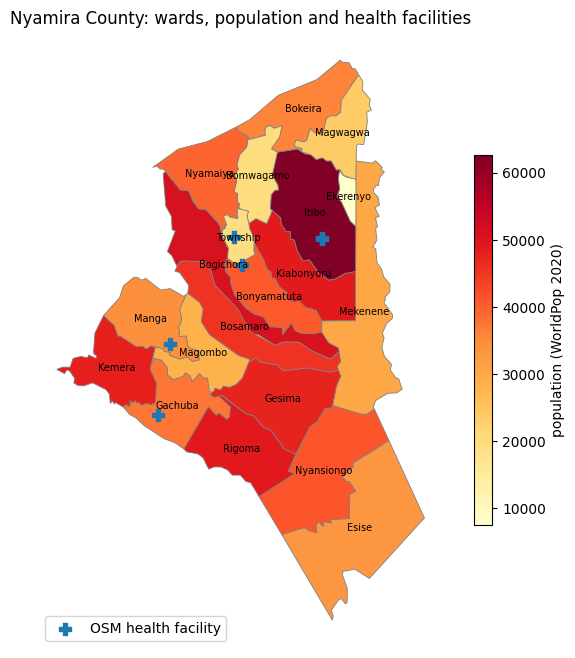

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
wards.plot(column="pop", cmap="YlOrRd", legend=True, edgecolor="grey", linewidth=0.6, ax=ax,
           legend_kwds={"label": "population (WorldPop 2020)", "shrink": 0.6})
fac.plot(ax=ax, color="tab:blue", marker="P", markersize=70, label="OSM health facility", zorder=3)
for _, r in wards.iterrows():
    ax.annotate(r.ward, (r.lon, r.lat), fontsize=7, ha="center", va="center")
ax.set_title(f"{COUNTY} County: wards, population and health facilities"); ax.set_axis_off(); ax.legend(loc="lower left")
plt.show()

## 2. A demand simulator with spillover

Historical vaccination demand per ward is not public, so we simulate it, and we make the dependence on the routing decision explicit. Let $y_j = 1$ if the clinic visits ward $j$. The *exposure* of ward $i$ to visits nearby is

$$E_i(y) = \min\Bigl(1,\ \sum_{j \neq i} w_{ij}\, y_j\Bigr), \qquad w_{ij} = \exp(-d_{ij} / R),$$

with $d_{ij}$ the road distance and $R$ the spillover range. One adjacent visit at 4.5 km gives an exposure of about 0.6; two saturate it, so the effect is bounded and demand cannot collapse to zero. Realised demand at ward $i$ is

$$D_i(y) = b_i \,\bigl(1 + \gamma\, E_i(y)\bigr)\, \varepsilon_i, \qquad \varepsilon_i \sim \text{LogNormal}(0, 0.15),$$

where the base demand $b_i$ grows with population, the unvaccinated share, and inaccessibility (road distance to the nearest facility). The sign of $\gamma$ is the whole point:

- $\gamma < 0$: **cannibalisation**. People near a visited ward get vaccinated there, so a later visit to the neighbour finds less demand. This is the direction assumed in the thesis (Appendix 6.B, the overlap term).
- $\gamma > 0$: **mobilisation**. Community health volunteers, market-day traffic and word of mouth raise turnout in wards next to a visited one.

The clinic administers at most `CAP` doses per visit, so doses delivered at a visited ward are $\min(\text{CAP}, D_i(y))$.

In [8]:
wards["unvacc"] = rng.beta(4, 6, n)                                  # simulated share of unvaccinated adults
wards["inacc"] = wards.km_to_facility / wards.km_to_facility.max()   # 0 = next to a facility, 1 = farthest ward
base = (0.02 * wards["pop"] * wards["unvacc"] * (0.5 + wards["inacc"])).values   # people who would turn up if visited alone
FEAT = np.column_stack([np.log(wards["pop"]), wards["unvacc"], wards["inacc"]])   # static ward features known to the planner

def spillover_matrix(R):
    W = np.exp(-dist / R); np.fill_diagonal(W, 0.0); return W      # w_ij = exp(-d_ij / R), zero diagonal
W = spillover_matrix(R_KM)

def exposure(y):
    return np.minimum(1.0, W @ y)                                   # saturates once the neighbourhood is covered

def realised_demand(y, gamma, noise=0.15, rng=rng):
    mu = base * (1 + gamma * exposure(y))
    return np.clip(mu * rng.lognormal(0, noise, size=n), 0, None)

def delivered(y, gamma, reps=500):
    # expected doses actually delivered on route y, by simulation
    return np.mean([np.minimum(CAP, realised_demand(y, gamma))[y > 0.5].sum() for _ in range(reps)])

print("base demand per ward if visited alone (doses):"); print(pd.Series(base.round(0), index=wards.ward).to_string())

base demand per ward if visited alone (doses):
ward
Esise          361.0
Kiabonyoru     263.0
Mekenene       255.0
Nyansiongo     427.0
Gachuba        241.0
Gesima         548.0
Kemera         283.0
Magombo         97.0
Manga          214.0
Rigoma         557.0
Bokeira        233.0
Bomwagamo      142.0
Ekerenyo        65.0
Itibo          283.0
Magwagwa       226.0
Bogichora      209.0
Bonyamatuta    157.0
Bosamaro       217.0
Nyamaiya       281.0
Township        85.0


## 3. Learning the demand model from past deployments

This is the step the thesis leaves implicit: **where does a training set with the decision variable in it come from?** Here we play back the history of many past planning periods. In each, the clinic visited a random set of 3 to 10 wards and we observed the demand at every ward. Each observation is a row with the ward's static features and its exposure $E_i$ to that period's visits. A model $g$ then learns $D_i \approx g(\text{features}_i, E_i)$.

We fit two models per scenario: a linear regression (transparent, but mis-specified because the true effect is multiplicative) and a small ReLU network with one hidden layer of `HIDDEN` units, fitted with L-BFGS in a few seconds (well-specified, and still small enough to embed).

In [9]:
def make_training(gamma, periods=1500, kmin=3, kmax=10):
    X, T = [], []
    for _ in range(periods):
        y = np.zeros(n); y[rng.choice(n, rng.integers(kmin, kmax + 1), replace=False)] = 1
        d, E = realised_demand(y, gamma), exposure(y)
        X.append(np.column_stack([FEAT, E])); T.append(d)
    return np.vstack(X), np.concatenate(T)

_model_cache = {}
def fit_models(gamma):
    # cached on (gamma, R_KM, HIDDEN): a changed hands-on parameter triggers a refit
    key = (gamma, R_KM, HIDDEN)
    if key in _model_cache:
        return _model_cache[key]
    t = time.perf_counter()
    X, T = make_training(gamma)
    t_sim = time.perf_counter() - t
    lin = LinearRegression().fit(X, T)
    t_lin = time.perf_counter() - t - t_sim
    mlp = make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=HIDDEN, solver="lbfgs", max_iter=2000, random_state=0)).fit(X, T)
    t_mlp = time.perf_counter() - t - t_sim - t_lin
    print(f"gamma={gamma:+.2f}, R_KM={R_KM:g}, hidden={HIDDEN}: rows={len(T)}, R2 linear={lin.score(X, T):.3f}, R2 mlp={mlp.score(X, T):.3f}"
          f"  [simulate {t_sim:.1f} s, fit linear {t_lin:.1f} s, fit mlp {t_mlp:.1f} s]")
    _model_cache[key] = (lin, mlp)
    return lin, mlp

for g in (-0.5, +0.5):
    fit_models(g)

gamma=-0.50, R_KM=10, hidden=(8,): rows=30000, R2 linear=0.853, R2 mlp=0.918  [simulate 0.1 s, fit linear 0.0 s, fit mlp 4.2 s]


gamma=+0.50, R_KM=10, hidden=(8,): rows=30000, R2 linear=0.846, R2 mlp=0.896  [simulate 0.2 s, fit linear 0.0 s, fit mlp 1.6 s]


## 4. The routing model

An open path starts at the depot ward $s$ (`START_WARD`, where vaccines are collected) and visits at most $K$ wards. We maximise expected doses delivered minus a driving cost. This is the Lagrangian cousin of the prize-collecting TSP with a demand threshold used in the thesis; it avoids infeasible thresholds and keeps the model tiny.

**Sets and parameters.** $N$ the wards, $s \in N$ the depot, $A = \{(i,j) : i \neq j\}$ the arcs, $c_{ij}$ the road distance, $\mu$ the driving cost per km in doses (`DOSE_PER_KM`), $K$ the stop limit, $C$ the doses per visit (`CAP`), $w_{ij}$ the spillover weights, $f_i$ the static features of ward $i$, and $M = 4C$ a bound on demand.

**Variables.** $x_{ij} \in \{0,1\}$ if the clinic drives from $i$ to $j$; $y_i \in \{0,1\}$ if ward $i$ is visited; $E_i \in [0,1]$ its exposure; $\hat d_i \ge 0$ its demand as the planner sees it; $z_i \in [0, C]$ the doses delivered there.

$$
\begin{array}{rrcll}
\max & \displaystyle \sum_{i \in N} z_i \;-\; \mu \sum_{(i,j) \in A} c_{ij}\, x_{ij} \\[2mm]
\text{s.t.} & y_s = 1, \quad \displaystyle\sum_{j} x_{sj} = 1, \quad \sum_{j} x_{js} & = & 0 & \text{(the path starts at the depot)} \\
& \displaystyle\sum_{j \neq i} x_{ji} & = & y_i & \forall\, i \in N \setminus \{s\} \quad \text{(one arc into each visited ward)} \\
& \displaystyle\sum_{j \neq i} x_{ij} & \le & y_i & \forall\, i \in N \quad \text{(at most one arc out; the last stop has none)} \\
& \displaystyle\sum_{(i,j) \in A} x_{ij} & = & \displaystyle\sum_{i \in N} y_i - 1 & \text{(a path has one arc fewer than stops)} \\
& \displaystyle\sum_{i \in N} y_i & \le & K \\
& E_i & = & \min\Bigl(1, \displaystyle\sum_{j \neq i} w_{ij}\, y_j\Bigr) & \forall\, i \in N \quad \text{(exposure, as in the simulator)} \\
& \hat d_i & \le & g(f_i, E_i) + M (1 - y_i) & \forall\, i \in N \quad \text{(the demand model)} \\
& z_i & \le & \hat d_i, \qquad z_i \le C\, y_i & \forall\, i \in N \quad \text{(deliver at most demand, at most capacity, only if visited)} \\
& \displaystyle\sum_{i, j \in S} x_{ij} & \le & \displaystyle\sum_{i \in S} y_i - y_k & \forall\, S \subseteq N \setminus \{s\},\ |S| \ge 2,\ k \in S \quad \text{(no subtours)}
\end{array}
$$

The last family is the Dantzig-Fulkerson-Johnson subtour elimination in its prize-collecting form: for a plain TSP it reads $\sum_{i,j \in S} x_{ij} \le |S| - 1$, and subtracting $y_k$ keeps it valid when the wards in $S$ are not all visited. There are exponentially many, so none is in the model up front. Whenever Gurobi finds an incumbent, a `MIPSOL` callback follows the successor arcs from the depot, and every visited ward it does not reach lies on a cycle $S$; the cut for that $S$ is then added with `cbLazy`. The mechanics, and a comparison with the Miller-Tucker-Zemlin alternative, are worked out in the MO-book chapter [Traveling Salesman Problem](https://mobook.github.io/MO-book/notebooks/04/08-traveling-salesman-problem.html), section "Revisiting the implementation: lazy constraint generation". Lazy cuts live outside the model that the Community Edition sizes, so the constraint counts printed below include none of them.

Three ways to fill in $g$, the demand model the objective rewards:

| Variant | Thesis analogue | How $\hat d_i$ enters |
| --- | --- | --- |
| **static** | Intervention I2, predict-then-optimize | $\hat d_i = g(\text{features}_i, E_i = 0)$, a number computed before solving |
| **learned** | Intervention I3, constraint learning | $\hat d_i = g(\text{features}_i, E_i(y))$ with $g$ embedded via `add_predictor_constr`, so $\hat d_i$ moves with $y$ inside the solver |
| **oracle** | upper bound | the true mean $b_i(1+\gamma E_i(y))$, which is linear in $y$ |

The `variables`/`constraints` counts printed below stay well under the Community Edition limit of 2000.

In [10]:
def build_model(variant, gamma, predictor=None, K=None):
    K = K_STOPS if K is None else K                            # read the hands-on value at call time
    m = gp.Model(); m.Params.OutputFlag = 0; m.Params.TimeLimit = 120
    arcs = [(i, j) for i in range(n) for j in range(n) if i != j]
    x = m.addVars(arcs, vtype=GRB.BINARY, name="x")
    y = m.addVars(n, vtype=GRB.BINARY, name="y")
    s = start
    m.addConstr(y[s] == 1)
    m.addConstr(gp.quicksum(x[s, j] for j in range(n) if j != s) == 1)
    m.addConstr(gp.quicksum(x[j, s] for j in range(n) if j != s) == 0)
    for i in range(n):
        if i != s:
            m.addConstr(gp.quicksum(x[j, i] for j in range(n) if j != i) == y[i])
        m.addConstr(gp.quicksum(x[i, j] for j in range(n) if j != i) <= y[i])
    m.addConstr(x.sum() == y.sum() - 1)                       # open path: one fewer arc than stops
    m.addConstr(y.sum() <= K)
    # Subtours are cut off lazily (DFJ) in subtour_callback below, not by constraints in the model.

    Eraw = m.addVars(n, lb=0, ub=float(W.sum(1).max()), name="Eraw")
    E = m.addVars(n, lb=0, ub=1, name="E")                     # exposure, capped at 1 exactly as in the simulator
    for i in range(n):
        m.addConstr(Eraw[i] == gp.quicksum(W[i, j] * y[j] for j in range(n) if j != i))
        m.addGenConstrMin(E[i], [Eraw[i]], constant=1.0)
    dhat = m.addVars(n, lb=0, ub=4 * CAP, name="dhat")

    if variant == "oracle":
        for i in range(n):
            m.addConstr(dhat[i] <= base[i] * (1 + gamma * E[i]))
    elif variant == "static":
        pred = predictor.predict(np.column_stack([FEAT, np.zeros(n)]))
        for i in range(n):
            m.addConstr(dhat[i] <= max(float(pred[i]), 0.0))
    elif variant == "learned":
        feats = m.addMVar((n, 4), name="feat")                # 3 fixed features + the exposure variable
        for i in range(n):
            for k in range(3):
                feats[i, k].LB = feats[i, k].UB = FEAT[i, k]
            m.addConstr(feats[i, 3] == E[i])
        out = m.addMVar((n, 1), lb=-GRB.INFINITY, name="g")
        add_predictor_constr(m, predictor, feats, out)          # the learned constraints
        for i in range(n):
            m.addConstr(dhat[i] <= out[i, 0] + 4 * CAP * (1 - y[i]))   # M = 4C frees dhat at unvisited wards
    else:
        raise ValueError(variant)

    z = m.addVars(n, lb=0, ub=CAP, name="z")                   # doses delivered
    for i in range(n):
        m.addConstr(z[i] <= dhat[i]); m.addConstr(z[i] <= CAP * y[i])
    m.setObjective(z.sum() - DOSE_PER_KM * gp.quicksum(dist[i, j] * x[i, j] for i, j in arcs), GRB.MAXIMIZE)
    m._x, m._y, m._s, m._cuts = x, y, s, 0
    m.Params.LazyConstraints = 1
    m.update()
    return m, x, y, z

def subtour_callback(model, where):
    # Dantzig-Fulkerson-Johnson subtour elimination, generated lazily: called on every new incumbent.
    # The degree constraints make an incumbent a path from the start plus, possibly, disjoint cycles
    # among visited wards. Each cycle S gets the prize-collecting cut  x(S) <= y(S) - y_k  for every k in S,
    # which is valid whether or not the wards in S are visited.
    if where != GRB.Callback.MIPSOL:
        return
    xv = model.cbGetSolution(model._x)
    succ = {i: j for (i, j), v in xv.items() if v > 0.5}
    onpath, k = {model._s}, model._s
    while k in succ and succ[k] not in onpath:
        k = succ[k]; onpath.add(k)
    seen = set()
    for i in succ:
        if i in onpath or i in seen:
            continue
        S, k = [], i
        while k in succ and k not in seen:
            seen.add(k); S.append(k); k = succ[k]
        inside = gp.quicksum(model._x[a, b] for a in S for b in S if a != b)
        y_in_S = gp.quicksum(model._y[a] for a in S)
        for k in S:
            model.cbLazy(inside <= y_in_S - model._y[k])
        model._cuts += 1

def solve(variant, gamma, predictor=None, label=None):
    t = time.perf_counter()
    m, x, y, z = build_model(variant, gamma, predictor)
    t_build = time.perf_counter() - t
    m.optimize(subtour_callback)
    t_solve = time.perf_counter() - t - t_build
    print(f"  {label or variant:20s} gamma={gamma:+.2f}: {m.NumVars} vars, {m.NumConstrs} constrs, "
          f"build {t_build:.2f} s, Gurobi {t_solve:.2f} s, {m._cuts} subtours cut, status {m.Status}, MIP gap {m.MIPGap:.1%}")
    ysol = np.array([y[i].X for i in range(n)])
    order = [start]
    while True:
        nxt = [j for j in range(n) if j != order[-1] and x[order[-1], j].X > 0.5]
        if not nxt: break
        order.append(nxt[0])
    km = sum(dist[a, b] for a, b in zip(order[:-1], order[1:]))
    promised = sum(z[i].X for i in range(n))
    return dict(variant=label or variant, gamma=gamma, stops=len(order), km=round(km, 1),
                promised=round(promised, 0), realised=round(delivered(ysol, gamma), 0),
                variables=m.NumVars, constraints=m.NumConstrs, seconds=round(time.perf_counter() - t, 1),
                route=[wards.ward[i] for i in order], order=order)

def run_scenario(gamma):
    global W
    with timed(f"scenario gamma={gamma:+.2f} (R_KM={R_KM:g}, K_STOPS={K_STOPS}, hidden={HIDDEN})"):
        W = spillover_matrix(R_KM)                 # hands-on parameters may have changed since Section 2
        lin, mlp = fit_models(gamma)
        rows = [solve("static", gamma, lin, "static (I2)"),
                solve("learned", gamma, lin, "learned linear (I3)"),
                solve("learned", gamma, mlp, "learned MLP (I3)"),
                solve("oracle", gamma, None, "oracle")]
    df = pd.DataFrame(rows)
    df["realised / promised"] = (df.realised / df.promised).round(2)
    df["doses per km"] = (df.realised / df.km).round(1)        # the thesis's vaccine-efficiency measure
    return df

### Scenario A: cannibalisation ($\gamma = -0.5$)

In [11]:
resA = run_scenario(-0.5)
resA.drop(columns=["order"])

Set parameter Username


Set parameter LicenseID to value 2749948


Academic license - for non-commercial use only - expires 2026-12-04


  static (I2)          gamma=-0.50: 480 vars, 124 constrs, build 0.08 s, Gurobi 0.61 s, 21 subtours cut, status 2, MIP gap 0.0%


  learned linear (I3)  gamma=-0.50: 580 vars, 164 constrs, build 0.18 s, Gurobi 0.90 s, 18 subtours cut, status 2, MIP gap 0.0%


  learned MLP (I3)     gamma=-0.50: 980 vars, 404 constrs, build 0.18 s, Gurobi 1.69 s, 13 subtours cut, status 2, MIP gap 0.0%


  oracle               gamma=-0.50: 480 vars, 124 constrs, build 0.04 s, Gurobi 0.78 s, 9 subtours cut, status 2, MIP gap 0.0%
[scenario gamma=-0.50 (R_KM=10, K_STOPS=8, hidden=(8,))] 4.6 s


,variant,gamma,stops,km,promised,realised,variables,constraints,seconds,route,realised / promised,doses per km
0,static (I2),-0.5,8,70.1,1889.0,1331.0,480,124,0.7,"[Township, Manga, Kemera, Gachuba, Rigoma, Ges...",0.70,19.0
1,learned linear (I3),-0.5,8,114.2,1630.0,1516.0,580,164,1.1,"[Township, Magwagwa, Mekenene, Esise, Nyansion...",0.93,13.3
2,learned MLP (I3),-0.5,8,117.1,1551.0,1530.0,980,404,1.9,"[Township, Bokeira, Mekenene, Esise, Nyansiong...",0.99,13.1
3,oracle,-0.5,8,117.1,1538.0,1530.0,480,124,0.8,"[Township, Bokeira, Mekenene, Esise, Nyansiong...",0.99,13.1


The static plan packs stops into the populous, accessible centre and promises more doses than turn up: each visit drains the neighbours it counted on. The learned MLP plan spreads stops out, drives further, and its promise matches what the simulator delivers; it lands on or next to the oracle route. The linear model is directionally right but mis-specified, so it lands in between. Watch the realised-to-promised ratio: that is the number a programme manager could compute after the fact.

### Scenario B: mobilisation ($\gamma = +0.5$)

In [12]:
resB = run_scenario(+0.5)
resB.drop(columns=["order"])

  static (I2)          gamma=+0.50: 480 vars, 124 constrs, build 0.05 s, Gurobi 0.10 s, 11 subtours cut, status 2, MIP gap 0.0%


  learned linear (I3)  gamma=+0.50: 580 vars, 164 constrs, build 0.13 s, Gurobi 0.11 s, 9 subtours cut, status 2, MIP gap 0.0%


  learned MLP (I3)     gamma=+0.50: 980 vars, 404 constrs, build 0.18 s, Gurobi 0.11 s, 9 subtours cut, status 2, MIP gap 0.0%
  oracle               gamma=+0.50: 480 vars, 124 constrs, build 0.03 s, Gurobi 0.07 s, 9 subtours cut, status 2, MIP gap 0.0%
[scenario gamma=+0.50 (R_KM=10, K_STOPS=8, hidden=(8,))] 0.9 s


,variant,gamma,stops,km,promised,realised,variables,constraints,seconds,route,realised / promised,doses per km
0,static (I2),0.5,8,73.1,1750.0,1876.0,480,124,0.2,"[Township, Nyamaiya, Itibo, Kiabonyoru, Mekene...",1.07,25.7
1,learned linear (I3),0.5,8,55.5,1852.0,1875.0,580,164,0.3,"[Township, Bogichora, Bosamaro, Gesima, Rigoma...",1.01,33.8
2,learned MLP (I3),0.5,8,52.7,1872.0,1855.0,980,404,0.3,"[Township, Bogichora, Bosamaro, Bonyamatuta, K...",0.99,35.2
3,oracle,0.5,8,55.5,1877.0,1876.0,480,124,0.1,"[Township, Bogichora, Bosamaro, Gesima, Rigoma...",1.00,33.8


Now the sign flips: the static planner does not know that clustered visits reinforce each other, so it under-promises and drives the same long loop as before. The learned-constraint planner clusters stops deliberately: the same doses for roughly a quarter less driving, so doses per km jump from about 26 to 35. With a capacity of `CAP` doses per visit the gain shows up in kilometres rather than in doses.

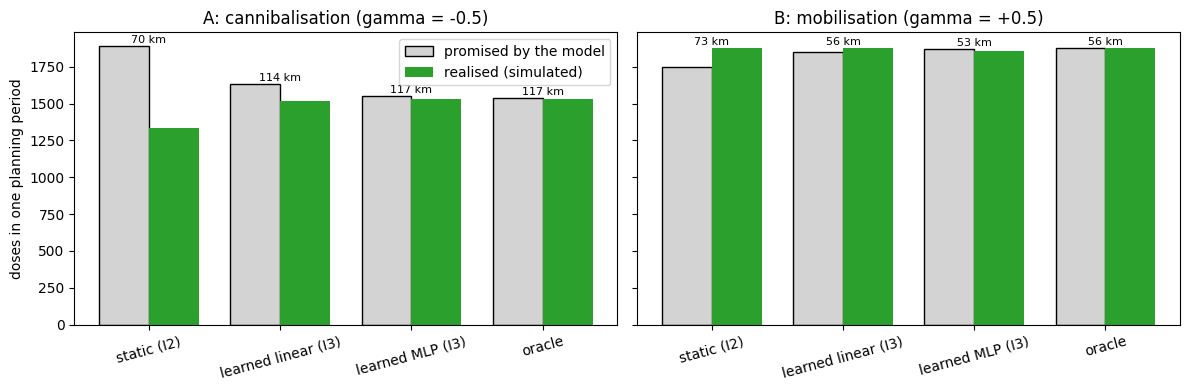

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, df, title in zip(axes, [resA, resB], ["A: cannibalisation (gamma = -0.5)", "B: mobilisation (gamma = +0.5)"]):
    xs = np.arange(len(df)); w = 0.38
    ax.bar(xs - w/2, df.promised, w, label="promised by the model", color="lightgrey", edgecolor="black")
    ax.bar(xs + w/2, df.realised, w, label="realised (simulated)", color="tab:green")
    ax.set_xticks(xs); ax.set_xticklabels(df.variant, rotation=15); ax.set_title(title)
    for i, r in df.iterrows():
        ax.annotate(f"{r.km:.0f} km", (i, max(r.promised, r.realised) + 20), ha="center", fontsize=8)
axes[0].set_ylabel("doses in one planning period"); axes[0].legend()
plt.tight_layout(); plt.show()

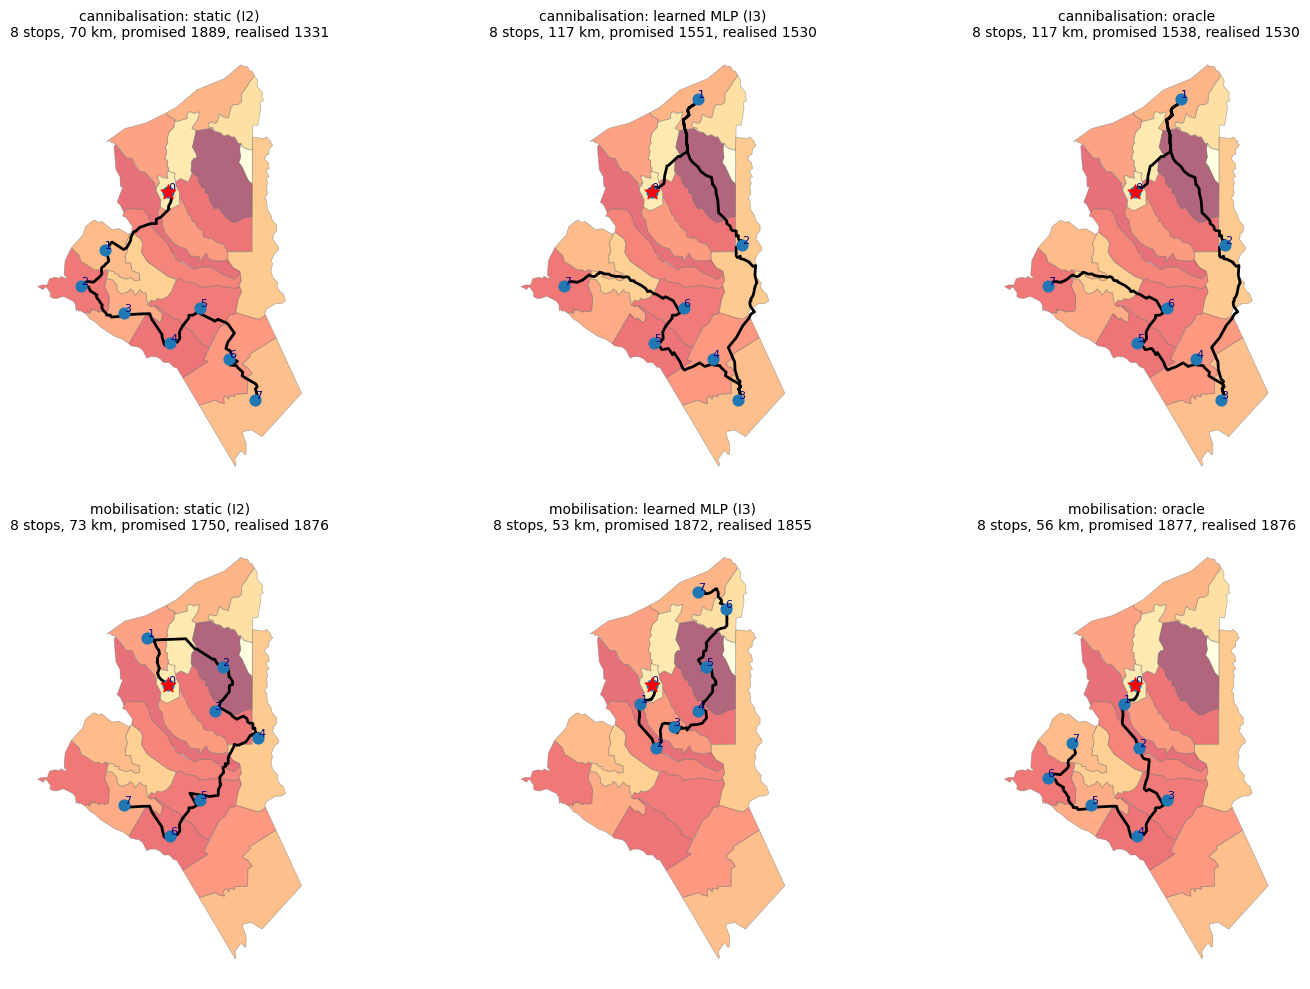

[road paths for 6 routes + figure] 6.6 s


In [14]:
def road_path(order):
    xy = []
    for a, b in zip(order[:-1], order[1:]):
        route = ox.routing.shortest_path(G, node_id[a], node_id[b], weight="length")
        xy += [(G.nodes[v]["x"], G.nodes[v]["y"]) for v in route]
    return np.array(xy)

t_fig = time.perf_counter()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for row, (df, gname) in enumerate([(resA, "cannibalisation"), (resB, "mobilisation")]):
    for col, variant in enumerate(["static (I2)", "learned MLP (I3)", "oracle"]):
        ax = axes[row, col]; r = df[df.variant == variant].iloc[0]
        wards.plot(column="pop", cmap="YlOrRd", alpha=0.6, edgecolor="grey", linewidth=0.5, ax=ax)
        p = road_path(r.order); ax.plot(p[:, 0], p[:, 1], color="black", linewidth=2)
        ax.scatter(wards.lon[r.order], wards.lat[r.order], s=60, color="tab:blue", zorder=3)
        ax.scatter(wards.lon[start], wards.lat[start], s=120, marker="*", color="red", zorder=4)
        for k, i in enumerate(r.order):
            ax.annotate(str(k), (wards.lon[i], wards.lat[i]), fontsize=8, ha="left", va="bottom", color="navy")
        ax.set_title(f"{gname}: {variant}\n{r.stops} stops, {r.km:.0f} km, promised {r.promised:.0f}, realised {r.realised:.0f}", fontsize=10)
        ax.set_axis_off()
plt.tight_layout(); plt.show()
print(f"[road paths for 6 routes + figure] {time.perf_counter() - t_fig:.1f} s")

## 5. Sweeping the spillover strength

How much does embedding the model buy, as a function of how strong the interaction is? For each $\gamma$ we retrain the models on that world's history and re-solve. At $\gamma = 0$ the three coincide, as they should. Under mobilisation the static plan delivers as many doses, so look at the right-hand panel: the learned plan reaches them with far less driving, which is what the objective rewards.

gamma=-0.80, R_KM=10, hidden=(8,): rows=30000, R2 linear=0.847, R2 mlp=0.944  [simulate 0.2 s, fit linear 0.0 s, fit mlp 3.3 s]
  static (I2)          gamma=-0.80: 480 vars, 124 constrs, build 0.04 s, Gurobi 0.06 s, 8 subtours cut, status 2, MIP gap 0.0%


  learned MLP (I3)     gamma=-0.80: 980 vars, 404 constrs, build 0.20 s, Gurobi 4.24 s, 14 subtours cut, status 2, MIP gap 0.0%


  oracle               gamma=-0.80: 480 vars, 124 constrs, build 0.03 s, Gurobi 1.08 s, 23 subtours cut, status 2, MIP gap 0.0%


  static (I2)          gamma=-0.50: 480 vars, 124 constrs, build 0.02 s, Gurobi 0.36 s, 21 subtours cut, status 2, MIP gap 0.0%


  learned MLP (I3)     gamma=-0.50: 980 vars, 404 constrs, build 0.07 s, Gurobi 0.87 s, 13 subtours cut, status 2, MIP gap 0.0%


...

gamma=+0.25, R_KM=10, hidden=(8,): rows=30000, R2 linear=0.848, R2 mlp=0.895  [simulate 0.1 s, fit linear 0.0 s, fit mlp 1.4 s]
  static (I2)          gamma=+0.25: 480 vars, 124 constrs, build 0.02 s, Gurobi 0.18 s, 10 subtours cut, status 2, MIP gap 0.0%


  learned MLP (I3)     gamma=+0.25: 980 vars, 404 constrs, build 0.06 s, Gurobi 0.05 s, 6 subtours cut, status 2, MIP gap 0.0%
  oracle               gamma=+0.25: 480 vars, 124 constrs, build 0.02 s, Gurobi 0.04 s, 8 subtours cut, status 2, MIP gap 0.0%
  static (I2)          gamma=+0.50: 480 vars, 124 constrs, build 0.02 s, Gurobi 0.07 s, 11 subtours cut, status 2, MIP gap 0.0%


  learned MLP (I3)     gamma=+0.50: 980 vars, 404 constrs, build 0.09 s, Gurobi 0.05 s, 9 subtours cut, status 2, MIP gap 0.0%
  oracle               gamma=+0.50: 480 vars, 124 constrs, build 0.01 s, Gurobi 0.03 s, 9 subtours cut, status 2, MIP gap 0.0%


gamma=+0.80, R_KM=10, hidden=(8,): rows=30000, R2 linear=0.843, R2 mlp=0.896  [simulate 0.1 s, fit linear 0.0 s, fit mlp 2.9 s]
  static (I2)          gamma=+0.80: 480 vars, 124 constrs, build 0.02 s, Gurobi 0.08 s, 12 subtours cut, status 2, MIP gap 0.0%


  learned MLP (I3)     gamma=+0.80: 980 vars, 404 constrs, build 0.08 s, Gurobi 0.06 s, 8 subtours cut, status 2, MIP gap 0.0%
  oracle               gamma=+0.80: 480 vars, 124 constrs, build 0.02 s, Gurobi 0.05 s, 11 subtours cut, status 2, MIP gap 0.0%
[full sweep: 7 gammas x (refit + 3 solves)] 21.7 s


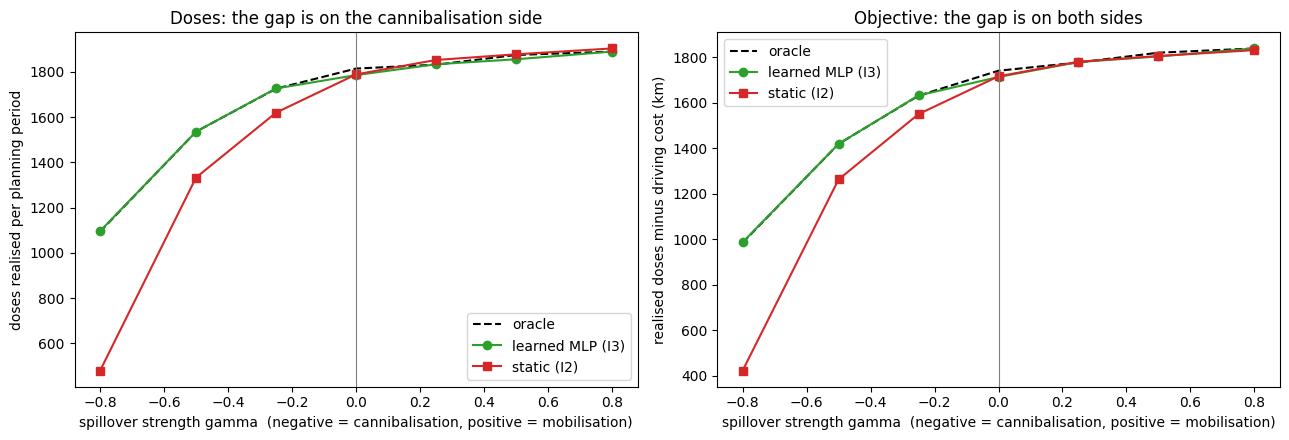

realised                                   km         \
variant learned MLP (I3)  oracle static (I2) learned MLP (I3) oracle   
gamma                                                                  
-0.80             1096.0  1094.0       479.0            109.0  109.0   
-0.50             1536.0  1536.0      1333.0            117.0  117.0   
-0.25             1727.0  1726.0      1620.0             95.0   95.0   
 0.00             1786.0  1815.0      1789.0             73.0   75.0   
 0.25             1834.0  1832.0      1853.0             56.0   56.0   
 0.50             1856.0  1875.0      1878.0             53.0   56.0   
 0.80             1890.0  1890.0      1904.0             52.0   52.0   

                     
variant static (I2)  
gamma                
-0.80          56.0  
-0.50          70.0  
-0.25          70.0  
 0.00          73.0  
 0.25          73.0  
 0.50          73.0  
 0.80          73.0

In [15]:
sweep = []
with timed("full sweep: 7 gammas x (refit + 3 solves)"):
    for g in [-0.8, -0.5, -0.25, 0.0, 0.25, 0.5, 0.8]:
        lin, mlp = fit_models(g)
        for variant, pred, label in [("static", lin, "static (I2)"), ("learned", mlp, "learned MLP (I3)"), ("oracle", None, "oracle")]:
            r = solve(variant, g, pred, label); sweep.append(dict(gamma=g, variant=label, realised=r["realised"], promised=r["promised"], km=r["km"]))
sweep = pd.DataFrame(sweep)
sweep["realised objective"] = sweep.realised - DOSE_PER_KM * sweep.km      # what the planner optimises, evaluated on realised demand

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, ylab in [(axes[0], "realised", "doses realised per planning period"), (axes[1], "realised objective", "realised doses minus driving cost (km)")]:
    for label, sty in [("oracle", dict(color="black", ls="--")), ("learned MLP (I3)", dict(color="tab:green", marker="o")), ("static (I2)", dict(color="tab:red", marker="s"))]:
        d = sweep[sweep.variant == label]; ax.plot(d.gamma, d[col], label=label, **sty)
    ax.axvline(0, color="grey", lw=0.8); ax.set_xlabel("spillover strength gamma  (negative = cannibalisation, positive = mobilisation)")
    ax.set_ylabel(ylab); ax.legend()
axes[0].set_title("Doses: the gap is on the cannibalisation side"); axes[1].set_title("Objective: the gap is on both sides")
plt.tight_layout(); plt.show()
sweep.pivot(index="gamma", columns="variant", values=["realised", "km"]).round(0)

In [16]:
# Interactive map of scenario A (static vs learned MLP). Open the notebook in Jupyter or Colab to interact.
import folium
mp = folium.Map(location=[wards.lat.mean(), wards.lon.mean()], zoom_start=11, tiles="OpenStreetMap")   # OSM tiles need no API key
folium.Choropleth(geo_data=wards.__geo_interface__, data=wards, columns=["ward", "pop"], key_on="feature.properties.ward",
                  fill_color="YlOrRd", fill_opacity=0.5, line_opacity=0.4, legend_name="population").add_to(mp)
for _, f in fac.iterrows():
    folium.CircleMarker([f.geometry.y, f.geometry.x], radius=5, color="blue", fill=True, tooltip=str(f.get("name", "facility"))).add_to(mp)
for variant, color in [("static (I2)", "red"), ("learned MLP (I3)", "green")]:
    r = resA[resA.variant == variant].iloc[0]; p = road_path(r.order)
    folium.PolyLine([(y_, x_) for x_, y_ in p], color=color, weight=4, opacity=0.8, tooltip=f"{variant}: {r.km} km, realised {r.realised:.0f} doses").add_to(mp)
    for k, i in enumerate(r.order):
        folium.Marker([wards.lat[i], wards.lon[i]], icon=folium.DivIcon(html=f'<div style="color:{color};font-weight:bold">{k}</div>')).add_to(mp)
mp

## 6. Takeaways, and how to adapt this

- **The planner's error is structural, not statistical.** In scenario A both the static and the learned linear model are trained on the same history; the static one just cannot let demand respond to the plan. The realised-to-promised ratio is the diagnostic to report in practice.
- **Both signs of spillover matter and pull the route in opposite directions**: cannibalisation spreads stops out, mobilisation clusters them. A planner that assumes independence does neither.
- **Where the training data comes from must be stated.** Here it is a replayed history of random deployments. In a real deployment it would be past periods' routes and ticketed turnout, which is exactly the feedback loop AMREF stakeholders asked for in the thesis.
- **Size.** With 20 wards, 8 stops and an 8-unit ReLU layer, the learned model has under 1000 variables and about 400 constraints, so it solves with a free `pip install gurobipy` licence in Colab; subtour cuts are generated lazily and do not count. Doubling the wards roughly quadruples the arc variables; drop to a linear or tree model, or prune arcs longer than a cutoff, before you exceed 2000.
- **To use your own data**: replace `base`, `unvacc` and the simulator with observed turnout per ward and period; keep `make_training` as the schema (features + exposure to that period's visits); swap the GADM level and `COUNTY` to change the geography.

## Appendix: answers to the hands-on experiments

Scenario A (cannibalisation, gamma = -0.5) rerun for each experiment. The hands-on parameters are restored afterwards.

In [17]:
_saved = (R_KM, K_STOPS, HIDDEN)
answers = []
with timed("hands-on answer table"):
    for label, (R_KM, K_STOPS, HIDDEN) in [("baseline", _saved),
                                            ("R_KM = 5", (5.0, _saved[1], _saved[2])), ("R_KM = 20", (20.0, _saved[1], _saved[2])),
                                            ("K_STOPS = 4", (_saved[0], 4, _saved[2])), ("K_STOPS = 12", (_saved[0], 12, _saved[2])),
                                            ("HIDDEN = (2,)", (_saved[0], _saved[1], (2,)))]:
        df = run_scenario(-0.5).set_index("variant")
        s, l = df.loc["static (I2)"], df.loc["learned MLP (I3)"]
        answers.append({"experiment": label, "static realised": s.realised, "static promised": s.promised, "static km": s.km,
                        "learned realised": l.realised, "learned promised": l.promised, "learned km": l.km,
                        "learned variables": l.variables, "gain (doses)": l.realised - s.realised})
R_KM, K_STOPS, HIDDEN = _saved
W = spillover_matrix(R_KM)
pd.DataFrame(answers).set_index("experiment")

  static (I2)          gamma=-0.50: 480 vars, 124 constrs, build 0.02 s, Gurobi 0.33 s, 21 subtours cut, status 2, MIP gap 0.0%


  learned linear (I3)  gamma=-0.50: 580 vars, 164 constrs, build 0.06 s, Gurobi 0.53 s, 18 subtours cut, status 2, MIP gap 0.0%


  learned MLP (I3)     gamma=-0.50: 980 vars, 404 constrs, build 0.09 s, Gurobi 1.09 s, 13 subtours cut, status 2, MIP gap 0.0%


  oracle               gamma=-0.50: 480 vars, 124 constrs, build 0.01 s, Gurobi 0.54 s, 9 subtours cut, status 2, MIP gap 0.0%
[scenario gamma=-0.50 (R_KM=10, K_STOPS=8, hidden=(8,))] 2.7 s


gamma=-0.50, R_KM=5, hidden=(8,): rows=30000, R2 linear=0.853, R2 mlp=0.908  [simulate 0.1 s, fit linear 0.0 s, fit mlp 3.8 s]
  static (I2)          gamma=-0.50: 480 vars, 124 constrs, build 0.05 s, Gurobi 0.13 s, 15 subtours cut, status 2, MIP gap 0.0%


...

  static (I2)          gamma=-0.50: 480 vars, 124 constrs, build 0.03 s, Gurobi 0.33 s, 21 subtours cut, status 2, MIP gap 0.0%


  learned linear (I3)  gamma=-0.50: 580 vars, 164 constrs, build 0.05 s, Gurobi 0.40 s, 21 subtours cut, status 2, MIP gap 0.0%


  learned MLP (I3)     gamma=-0.50: 740 vars, 284 constrs, build 0.06 s, Gurobi 0.82 s, 23 subtours cut, status 2, MIP gap 0.0%


  oracle               gamma=-0.50: 480 vars, 124 constrs, build 0.02 s, Gurobi 0.43 s, 9 subtours cut, status 2, MIP gap 0.0%
[scenario gamma=-0.50 (R_KM=10, K_STOPS=8, hidden=(2,))] 2.7 s
[hands-on answer table] 15.9 s


,static realised,static promised,static km,learned realised,learned promised,learned km,learned variables,gain (doses)
experiment,,,,,,,,
baseline,1330.0,1889.0,70.1,1529.0,1551.0,117.1,980,199.0
R_KM = 5,1625.0,1823.0,73.1,1791.0,1814.0,98.3,980,166.0
R_KM = 20,1123.0,1923.0,55.5,1350.0,1348.0,75.4,980,227.0
K_STOPS = 4,453.0,889.0,27.9,819.0,822.0,38.4,980,366.0
K_STOPS = 12,1685.0,2889.0,108.2,1889.0,1921.0,129.7,980,204.0
"HIDDEN = (2,)",1333.0,1890.0,70.1,1533.0,1534.0,117.1,740,200.0


Reading the table. **Range:** at 5 km wards are nearly independent, so both plans deliver more and the gain is smallest. At 20 km every visit touches every ward; demand is lower for everyone, and the static model, trained on a history where exposure is almost always saturated, extrapolates badly to an exposure of zero, so its promise gap is the widest. **Stops:** with only 4 stops the static planner packs them into the dense cluster next to town, the worst possible choice under cannibalisation, so the relative gain is the largest of all; with 12 stops overlap is unavoidable for any planner and the gain settles. **Model size:** the two-unit network embeds with 240 fewer variables and captures this simple demand function just as well; with a richer demand function it would start to lag behind.